## Простейшие алгоритмы рекомендаций

In [21]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from typing import List, Optional

%matplotlib inline

## Задание

Работа посвящена исследованию простейших моделей рекомендаций.
Как правило, они не требуют обучения специальных моделей, но могут быть полезны в качестве бейзлайна.

<u>Исходные данные</u>: датасет по рекомендации фильмов от Kion MTS.

Потребуются файлы `interactions.csv` и `items.csv`

Для преобработки данных можно использовать функции из [примера](https://colab.research.google.com/drive/1Ce0AVEiWUhpzovCMN6eQNqEUKmPxq2Z3?usp=sharing).


Шаблоны функций и классов ниже можно менять по своему усмотрению.

In [22]:
df = pd.read_csv('interactions.csv').iloc[:-1]
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [23]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
378529,756418,14317,130,5349,82.0
3630052,983014,15994,99,1292,20.0
3412056,374229,2657,140,8449,11.0
4634131,1087586,5693,82,462,7.0
3275286,883909,1857,159,7135,99.0


Сделаем разбиение по времени

<Axes: >

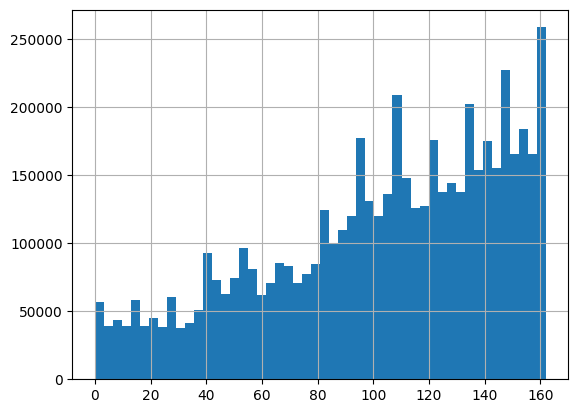

In [24]:
df.last_watch_dt.hist(bins=50)

In [25]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [26]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

И переведём всё к соединённому датасету:

In [27]:
n_users = 10000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users

In [28]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
73,820464,3071,35,4708,80.0
112,490158,817,139,930,16.0
114,806082,579,110,836,11.0
131,470881,11800,100,909,19.0
207,170430,12148,66,111,0.0


In [29]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

C:\Users\andre\AppData\Local\Temp\ipykernel_9040\1105526701.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('user_id').apply(
C:\Users\andre\AppData\Local\Temp\ipykernel_9040\1105526701.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('user_id').apply(


,user_id,train_interactions
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399..."
4,446,"[(13865, 105)]"


In [30]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]"
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]"


In [31]:
np.random.seed(777)

class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=10):
        assert self.trained
        return [np.random.choice(self.items, replace=False, size=topn)]*len(df)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=3)
joined.head()

,user_id,train_interactions,test_interactions,random_recs
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337...","[1975, 16006, 3059]"
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213...","[1975, 16006, 3059]"
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[1975, 16006, 3059]"
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]","[1975, 16006, 3059]"
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[1975, 16006, 3059]"


**Задание №1. Метрики и бейзлайны**

Напишите функцию для рассчета метрик AP, RR, HR.

$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$

$$
p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)
$$

$$
RR@k = \dfrac{1}{\text{rank}_i@k}
$$

$$
HR@k = [\exists \ y_i = 1 \ \text{among k preds}]
$$


*   $n_u$ - число айтемов, с которыми взаимодействовал юзер $u$
*   $y_i \in \{0,1\}$ - релевантно ли $i$-ое предсказание
* $\text{rank}_i@k$ - позиция первого релевантого айтема среди первых $k$ предсказаний
* HR@k - среди первых $k$ предсказаний есть хотя бы одно релевантное

In [32]:

def ap_metric(gt_items, predictions, topn=None):
    if topn is not None: predictions=predictions[:topn]
    gt=set(gt_items); hits=0; s=0.0
    for i,item in enumerate(predictions,1):
        if item in gt:
            hits+=1; s+=hits/i
    return s/max(1,len(gt))

def rr_metric(gt_items,predictions,topn=None):
    if topn is not None: predictions=predictions[:topn]
    gt=set(gt_items)
    for i,item in enumerate(predictions,1):
        if item in gt: return 1/i
    return 0.0

def hr_metric(gt_items,predictions,topn=None):
    if topn is not None: predictions=predictions[:topn]
    gt=set(gt_items)
    return float(any(x in gt for x in predictions))


Усредняем метрики по юзерам.

In [33]:
def evaluate_recommender(df, model_preds, gt_col='test_interactions'):

    metric_values = []

    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        predictions = row[model_preds]

        ap = ap_metric(gt_items, predictions)
        rr = rr_metric(gt_items, predictions)
        hr = hr_metric(gt_items, predictions)

        metric_values.append((ap, rr, hr))

    return {'map': np.mean([x[0] for x in metric_values]),
            'mrr': np.mean([x[1] for x in metric_values]),
            'hr': np.mean([x[2] for x in metric_values])}

Если всё сделаено правильно, рандомные предсказания должны дать хоть какое-то качество, но не очень большое.

In [34]:
evaluate_recommender(joined, model_preds='random_recs')

{'map': np.float64(5.145833333333333e-05),
 'mrr': np.float64(0.00025),
 'hr': np.float64(0.0005)}

In [35]:
class TopPopular:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        self.recommenations = [x[0] for x in counts]
        self.trained = True

    def predict(self, df, topn=10)  -> List[np.ndarray]:

        assert self.trained
        return [self.recommenations[:topn]]*len(df)


toppop = TopPopular()
toppop.fit(joined)

joined['toppopular_recs'] = toppop.predict(joined)
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337...","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213...","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."


Самые популярные предсказания должны показать более высокое качество.

In [36]:
evaluate_recommender(joined, model_preds='toppopular_recs')

{'map': np.float64(0.06643721029727002),
 'mrr': np.float64(0.11853710317460318),
 'hr': np.float64(0.2996)}

**Задание №2. Рекомендации в окне**

Необходимо переделать метод рекомендации по популярности так, что популярность считается только за какое-то более свежее временное окно. Под окном подразумевается какой-то временной промежуток, например, ближайший месяц, соответственно, всё что за его пределами, не учитывается.

In [37]:
class TopPopularWeighted(TopPopular):
    def __init__(self,min_window=2):
        super().__init__()
        self.min_window=min_window
    def fit(self,df,col='train_interactions'):
        counts={}
        for _,row in df.iterrows():
            for item,_ in row[col][-self.min_window:]:
                counts[item]=counts.get(item,0)+1
        counts=sorted(counts.items(),key=lambda x:x[1],reverse=True)
        self.recommenations=[x[0] for x in counts]
        self.trained=True

Постройте графики зависимости значений трёх метрик (AP@k, RR@k, HR@k) от размера окна.

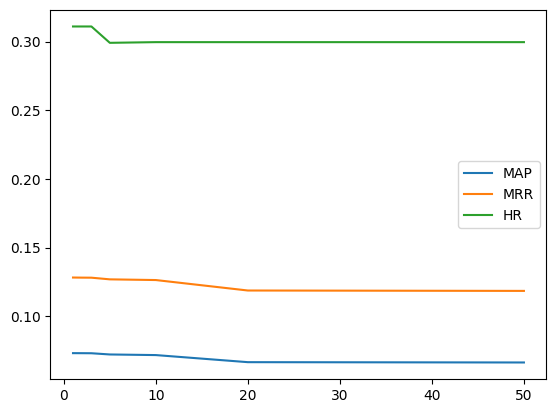

In [38]:
windows=[1,2,3,5,10,20,50]
res=[]
for w in windows:
    m=TopPopularWeighted(w); m.fit(joined)
    joined['tmp']=m.predict(joined)
    r=evaluate_recommender(joined,'tmp')
    res.append(r)
plt.plot(windows,[x['map'] for x in res],label='MAP')
plt.plot(windows,[x['mrr'] for x in res],label='MRR')
plt.plot(windows,[x['hr'] for x in res],label='HR')
plt.legend(); plt.show()

Как размер окна влияет на качество рекомендаций? Какое значение наилучшее?


**Задание №3. Метрики и k.**

Постройте зависимость значений MAP@K, MRR@K, HR@K для метода рекомендации по популярности. Возьмите k, например, от 1 до 100, переберите значения и покажите на линейном графике.

In [39]:
joined['toppopular_recs'] = toppop.predict(joined, topn=100)

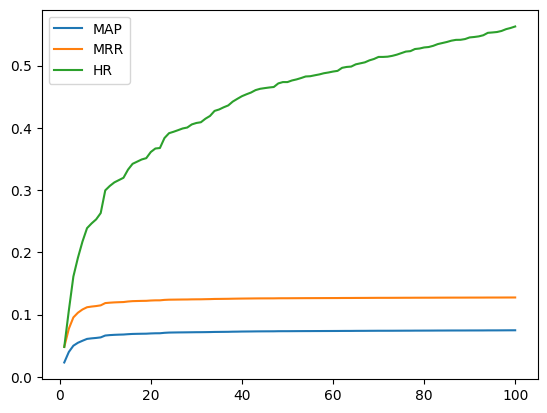

In [40]:
ks=range(1,101)
maps=[]; mrrs=[]; hrs=[]
for k in ks:
    joined['toppopular_recs']=toppop.predict(joined,topn=k)
    r=evaluate_recommender(joined,'toppopular_recs')
    maps.append(r['map']); mrrs.append(r['mrr']); hrs.append(r['hr'])
plt.plot(list(ks),maps,label='MAP')
plt.plot(list(ks),mrrs,label='MRR')
plt.plot(list(ks),hrs,label='HR')
plt.legend(); plt.show()

Какие из метрик являются монотонными функциями по top-K?

Как можно интерпретировать графики метрик? То есть, что можно сказать про связь изменения метрики c возможными пользовательскими сценариями, например,скроллингом ленты новостей.

**Задание №4. Интерпретация рейтингов**

Возьмите названия фильмов/сериалов из `items.csv`, выделите 5 различных сценариев изменения популярности у фильмов, аргументируйте (например, графиком или статистикой). Обратите внимание, что надо найти именно разные паттерны изменения вероятностей.

In [41]:
items = pd.read_csv('items.csv')[['item_id','title']].copy()
items.head()

,item_id,title
0,10711,Поговори с ней
1,2508,Голые перцы
2,10716,Тактическая сила
3,7868,45 лет
4,16268,Все решает мгновение


Пример:

1917


<Axes: >

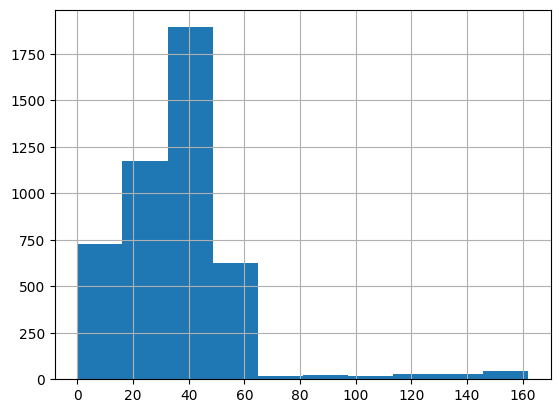

In [105]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

sampled_id = 3402

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist()

Фильм 1917 какое-то время набирал популярность, потом видим резкое падение (кстати, с какой даты?). Возможно, это связано с ограничением доступности этого фильма для части пользователей, периодом проката фильма / рекламной кампании или другой причиной.

Добавьте 5 своих примеров ниже. Опишите, как вы их искали.

In [43]:
# Примеры паттернов популярности: выбрать 5 item_id и построить hist по last_watch_dt

**Задание №5. User-item encoding**

Теперь, создайте матрицу интеракций user-item по [примеру](https://colab.research.google.com/drive/1Ce0AVEiWUhpzovCMN6eQNqEUKmPxq2Z3?usp=sharing). Вам нужно в итоге получить разреженную матрицу (sparse matrix), в которой в качестве строк будут пользователи, в качестве колонок - айтемы. Не забудьте перекодировать пользователей и айтемы через энкодер. Оставьте в матрице только юзеров и айтемы, которые встречались в матрице > 4 раз.

Важно: когда вы отфильтруете юзеров на встречаемость > 4 раз, вы удалите какие-то айтемы, которые теперь станут встречаться меньше 5 раз. Поэтому у вас перестанет выполняться второе условие на минимальное число интеракций с айтемом. Тогда вам надо опять отфильтровать айтемы на встречаемость, но это снова может нарушить условие для юзеров. В таком случае, вам надо написать итеративный алгоритм до сходимости, пока требования не будут выполняться в обеих колонках.

In [75]:
def filter_column(df,min_freq,col):
    vc=df[col].value_counts()
    return df[df[col].isin(vc[vc>=min_freq].index)].copy()

def filter_dataframe(df,cols,min_freq=5):
    df=df.copy()
    changed=True
    while changed:
        n=len(df)
        for col in cols:
            df=filter_column(df,min_freq,col)
        changed=len(df)!=n
    return df

filtered_train = filter_dataframe(train_df,['user_id','item_id'],5)

In [76]:
def df_encode(df):
    item2id = {k: v for v, k in enumerate(df.item_id.unique())}
    user2id = {k: v for v, k in enumerate(df.user_id.unique())}

    id2item = {v: k for k, v in item2id.items()}
    id2user = {v: k for k, v in user2id.items()}

    df = df.copy()
    df['user_id'] = df.user_id.map(user2id)
    df['item_id'] = df.item_id.map(item2id)

    return df, user2id, item2id, id2user, id2item

filtered_train, user2id, item2id, id2user, id2item = df_encode(filtered_train)
filtered_train.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
1667386,4446,2654,151,57,0.0
2387171,2382,15,58,1602,31.0
2239834,1127,775,111,8127,100.0
5077123,4701,1814,144,3421,40.0
324073,3053,1487,3,330347,100.0


In [110]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 108627 stored elements and shape (5884, 3031)>

**Задание №6. Интеракции и частота**

Постройте график зависимости количества айтемов и юзеров от значений (порогов) фильтров на встречаемость в матрице интеракций. То есть, нужно выполнить задание №5 для нескольких значений `min_freq` и построить график зависимости числа оставшихся айтемов и юзеров от этого параметра.

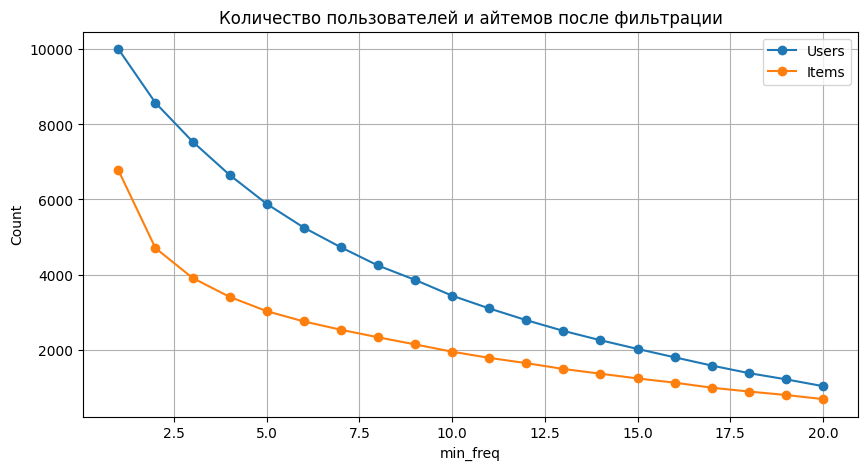

In [104]:
def filter_dataframe2(df, min_freq=5):

    while True:

        old_shape = df.shape[0]

        user_counts = df.user_id.value_counts()
        valid_users = user_counts[user_counts >= min_freq].index

        df = df[df.user_id.isin(valid_users)]

        item_counts = df.item_id.value_counts()
        valid_items = item_counts[item_counts >= min_freq].index

        df = df[df.item_id.isin(valid_items)]

        if old_shape == df.shape[0]:
            break

    return df

freqs = range(1, 21)

n_users = []
n_items = []

for freq in freqs:
    filtered = filter_dataframe2(train_df.copy(), min_freq=freq)

    n_users.append(filtered.user_id.nunique())
    n_items.append(filtered.item_id.nunique())

plt.figure(figsize=(10, 5))

plt.plot(freqs, n_users, marker='o', label='Users')
plt.plot(freqs, n_items, marker='o', label='Items')

plt.xlabel('min_freq')
plt.ylabel('Count')
plt.title('Количество пользователей и айтемов после фильтрации')
plt.grid(True)
plt.legend()

plt.show()

**Задание №7. EASE**

Реализуйте EASE, постройте рекомендации для юзеров. Сравните все имплементированные ранее метрики качества с `TopPopular` для некоторого набора k.

Реализацию можно взять из [примера](https://colab.research.google.com/drive/1Ce0AVEiWUhpzovCMN6eQNqEUKmPxq2Z3?usp=sharing).

 Можно реализовать по статье https://arxiv.org/pdf/1905.03375.pdf.

 Можно адаптировать из RecBole https://github.com/RUCAIBox/RecBole.

In [81]:
%%time
def fit_ease(X, reg_weight=1000):
    G=(X.T @ X).toarray()
    diag=np.arange(G.shape[0])
    G[diag,diag]+=reg_weight
    P=np.linalg.inv(G)
    B=-P/np.diag(P)
    B[diag,diag]=0
    return B

w=fit_ease(matrix)

CPU times: total: 5.97 s
Wall time: 635 ms


Далее, неоходимо реализовать функцию получения предсказаний. У вас есть обученная матрица весов, которую можно использовать для получения предсказаний. Для этого нужно построить вектор интеракций пользователя и умножить его на матрицу весов.

In [82]:
def get_preds(x,item2id,id2item):
    ids=[item2id[i] for i,_ in x if i in item2id]
    vec=np.zeros(len(item2id))
    vec[ids]=1
    scores=vec @ w
    scores[ids]=-np.inf
    top=np.argsort(scores)[::-1][:100]
    return [id2item[i] for i in top]

joined['ease_preds']=joined.train_interactions.apply(lambda x:get_preds(x,item2id,id2item))
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs,tmp,ease_preds
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337...","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[7571, 11749, 16270, 10761, 7582, 5411, 15266,..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213...","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[16166, 3182, 7571, 4718, 7582, 13243, 5411, 6..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[3734, 4151, 2657, 8636, 12192, 4457, 7829, 47..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[15297, 9728, 13865, 3734, 2657, 4151, 12192, ..."
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[1975, 16006, 3059]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 3734, 12995, 15297, 8636, 4495, ..."


In [83]:
evaluate_recommender(joined,'ease_preds')

{'map': np.float64(0.09805971881460275),
 'mrr': np.float64(0.1718764086224428),
 'hr': np.float64(0.6176)}

Какой алгоритм работает лучше?


**Задание №8. Тюнинг**

Переберите различные значения гиперпараметра коэффициента регуляризации у EASE и постройте графики, как в задании №6.

Processing reg=10
Processing reg=30
Processing reg=100
Processing reg=300
Processing reg=1000
Processing reg=3000
Processing reg=10000


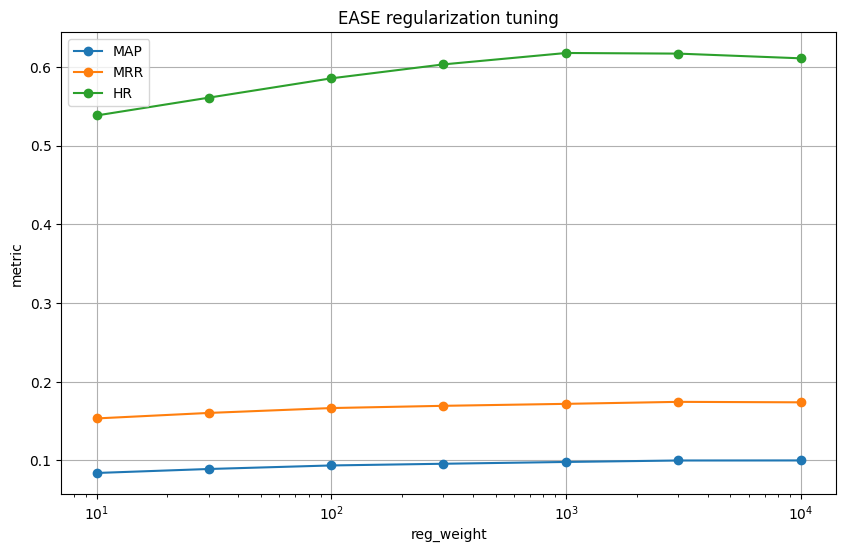

In [88]:
regs = [10, 30, 100, 300, 1000, 3000, 10000]

maps = []
mrrs = []
hrs = []

for reg in regs:
    print(f'Processing reg={reg}')

    # обучаем EASE
    w = fit_ease(matrix, reg_weight=reg)

    # пересчитываем рекомендации
    joined['ease_preds'] = joined.train_interactions.apply(
        lambda x: get_preds(x, item2id, id2item)
    )

    # считаем метрики
    metrics = evaluate_recommender(joined, 'ease_preds')

    maps.append(metrics['map'])
    mrrs.append(metrics['mrr'])
    hrs.append(metrics['hr'])

# графики как в задании №6
plt.figure(figsize=(10, 6))

plt.plot(regs, maps, marker='o', label='MAP')
plt.plot(regs, mrrs, marker='o', label='MRR')
plt.plot(regs, hrs, marker='o', label='HR')

plt.xscale('log')
plt.xlabel('reg_weight')
plt.ylabel('metric')
plt.title('EASE regularization tuning')
plt.grid(True)
plt.legend()

plt.show()

**Задание №9. EASE и topk**

Качество у EASE растет с ослаблением фильтра на число айтемов. Постройте кривые метрик качества MAP/MRR/HR в зависимости от topk (например, от 1 до 100 с некоторым шагом), где кривая параметризована минимальным требуемым значением встречаемости user/item (из задания №6). Опишите свои выводы.

Важно: в этом задании линии могут быть мало различимыми, поэтому ваша задача для каждой метрики найти нужный масштаб на каких-то конкретных topk, чтобы линии стали визуально отличимы.

**Задание №10. Интерпретируемые рекомендации**

Используйте выученную матрицу весов для item2item рекомендаций. Приведите 10 примеров топ-5 рекомендаций от EASE к сэмплируемым айтемам. Используйте названия фильмов вместо id при выводе рекомендаций.

In [112]:
items = pd.read_csv('items.csv')

# словарь item_id -> название
item_names = dict(zip(items['item_id'], items['title']))

sample_items = np.random.choice(list(item2id.keys()), size=10, replace=False)

for item_id in sample_items:

    item_idx = item2id[item_id]

    # топ похожих фильмов по весам EASE
    top_idx = np.argsort(w[item_idx])[::-1][:5]

    print("=" * 80)
    print("Фильм:")
    print(item_names.get(item_id, str(item_id)))

    print("\nРекомендации:")

    for idx in top_idx:
        rec_item = id2item[idx]
        print("-", item_names.get(rec_item, str(rec_item)))

Фильм:
Чудачества любви не помеха! Положись на меня

Рекомендации:
- Дети моря
- Помни меня
- Ледниковый период 4: Континентальный дрейф
- Подслушано
- Эхо террора
Фильм:
Команда мечты

Рекомендации:
- Страсти Дон Жуана
- Король лев (2019)
- Клиника счастья
- Маленький воин
- Девятаев
Фильм:
Игра

Рекомендации:
- Маша
- Афера
- Прабабушка легкого поведения
- #Только серьёзные отношения
- Аферистка
Фильм:
Идеальная пара

Рекомендации:
- Хрустальный
- Прабабушка легкого поведения
- Гнев человеческий
- Стендап под прикрытием
- Афера
Фильм:
Про Любовь

Рекомендации:
- Клиника счастья
- Секреты семейной жизни
- Прабабушка легкого поведения
- Маша
- Про любовь. Только для взрослых
Фильм:
Воробьишка - хвастунишка

Рекомендации:
- Мама для мамонтенка
- Ишь ты, масленица
- Крошка Енот
- Большой Ух
- Зов джунглей
Фильм:
Крик тишины

Рекомендации:
- Бункер
- Простые сложности
- Маша
- Хороший доктор
- В тихом омуте
Фильм:
Смертельная гонка 4: Вне анархии

Рекомендации:
- Мумия
- Мстители: Финал
-

Есть ли хорошие примеры рекомендации? А плохие?